In [1]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time, os

In [2]:
# ---------------------------
# ✅ CONFIG
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = ["Dry", "Normal", "Oily"]
resize = 224
test_dir = "SkinType_Dataset/test"
BS = 32

In [3]:
# ---------------------------
# ✅ TRANSFORM & DATALOADER
# ---------------------------
test_tf = transforms.Compose([
    transforms.Resize((resize, resize)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_ds = datasets.ImageFolder(test_dir, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=BS, shuffle=False)

In [4]:
# ---------------------------
# ✅ MODEL LOADER FUNCTION
# ---------------------------
def load_model(model_name, weights_path):
    if model_name == "resnet50":
        model = models.resnet50()
        model.fc = nn.Linear(model.fc.in_features, len(classes))
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0()
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2()
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
    else:
        raise ValueError("Unknown model name")

    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model

In [5]:
# ---------------------------
# ✅ EVALUATE FUNCTION
# ---------------------------
def evaluate(model):
    all_preds, all_tgts = [], []
    start = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_tgts.extend(labels.cpu().numpy())
    infer_time = (time.time() - start) / len(test_ds)
    report = classification_report(all_tgts, all_preds, target_names=classes, output_dict=True)
    return report, infer_time

In [ ]:
# ---------------------------
# ✅ RUN EVALUATION FOR ALL MODELS
# ---------------------------
models_info = {
    "ResNet50": ("resnet50", "resnet50_skin_classifier.pth"),
    "EfficientNet-B0": ("efficientnet_b0", "efficientnet_skin_classifier.pth"),
    "MobileNetV2": ("mobilenet_v2", "mobilenetv2_skin_classifier.pth"),
}

results = {}

for name, (arch, path) in models_info.items():
    print(f"\n🔹 Evaluating {name} ...")
    model = load_model(arch, path)
    report, infer_time = evaluate(model)
    results[name] = {
        "accuracy": report["accuracy"],
        "precision": np.mean([report[c]["precision"] for c in classes]),
        "recall": np.mean([report[c]["recall"] for c in classes]),
        "f1": np.mean([report[c]["f1-score"] for c in classes]),
        "inference_time": infer_time * 1000  # ms per image
    }
    print(f"{name} → Acc: {report['accuracy']:.3f}, F1: {results[name]['f1']:.3f}, Time: {results[name]['inference_time']:.2f} ms")


🔹 Evaluating ResNet50 ...
ResNet50 → Acc: 0.836, F1: 0.877, Time: 28.98 ms

🔹 Evaluating EfficientNet-B0 ...
EfficientNet-B0 → Acc: 0.821, F1: 0.840, Time: 9.04 ms

🔹 Evaluating MobileNetV2 ...
MobileNetV2 → Acc: 0.750, F1: 0.766, Time: 6.35 ms


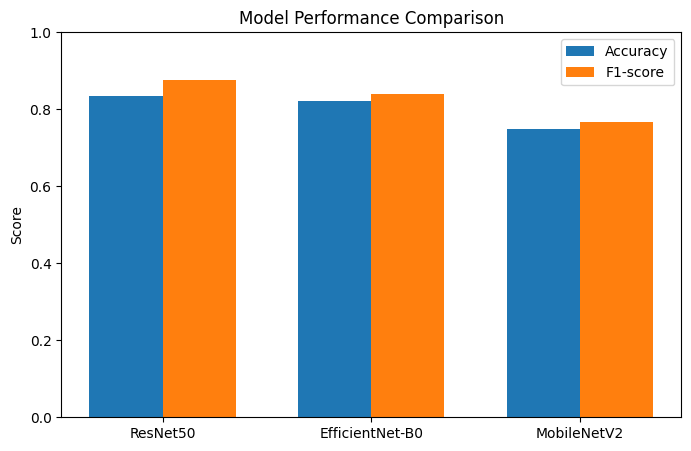

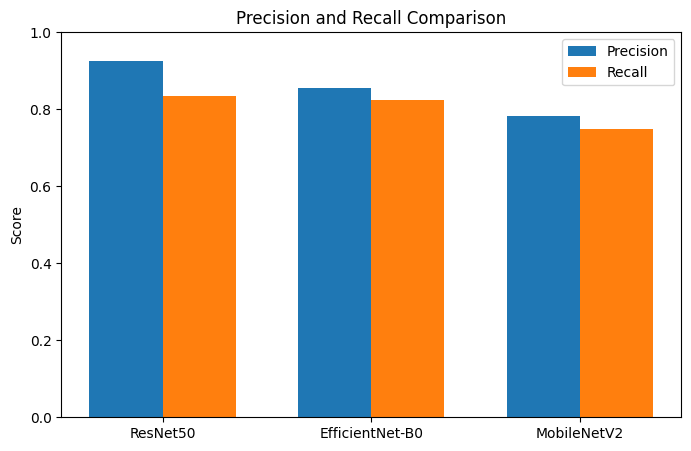

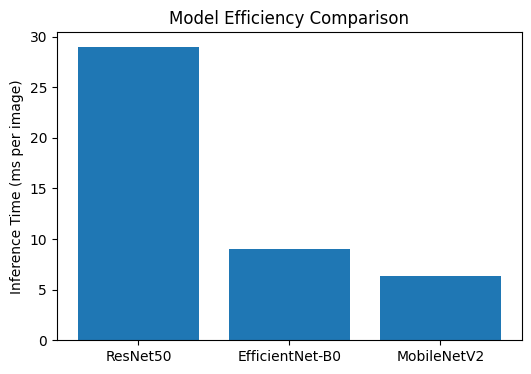

In [ ]:
# ---------------------------
# ✅ PLOT COMPARISON
# ---------------------------
models = list(results.keys())
acc = [results[m]["accuracy"] for m in models]
f1 = [results[m]["f1"] for m in models]
prec = [results[m]["precision"] for m in models]
rec = [results[m]["recall"] for m in models]
times = [results[m]["inference_time"] for m in models]

# ---- Accuracy & F1 ----
x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(8,5))
plt.bar(x - width/2, acc, width, label='Accuracy')
plt.bar(x + width/2, f1, width, label='F1-score')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.show()

# ---- Precision & Recall ----
plt.figure(figsize=(8,5))
plt.bar(x - width/2, prec, width, label='Precision')
plt.bar(x + width/2, rec, width, label='Recall')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.title("Precision and Recall Comparison")
plt.ylabel("Score")
plt.legend()
plt.show()

# ---- Inference Time ----
plt.figure(figsize=(6,4))
plt.bar(models, times, color='lightcoral')
plt.ylabel("Inference Time (ms per image)")
plt.title("Model Efficiency Comparison")
plt.show()
